# Week 7 - Vision Transformer on CIFAR-10

This notebook contains a complete CIFAR-10 image classification pipeline using a Vision Transformer.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import time

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

Device: cuda


In [2]:
from torch.utils.data import DataLoader, Subset

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

full_trainset_for_train = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

full_trainset_for_val = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_eval
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_eval
)

dataset_size = len(full_trainset_for_train)
train_size = int(0.8 * dataset_size)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(dataset_size, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

trainset = Subset(full_trainset_for_train, train_indices)
valset = Subset(full_trainset_for_val, val_indices)

trainloader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

valloader = DataLoader(
    valset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])


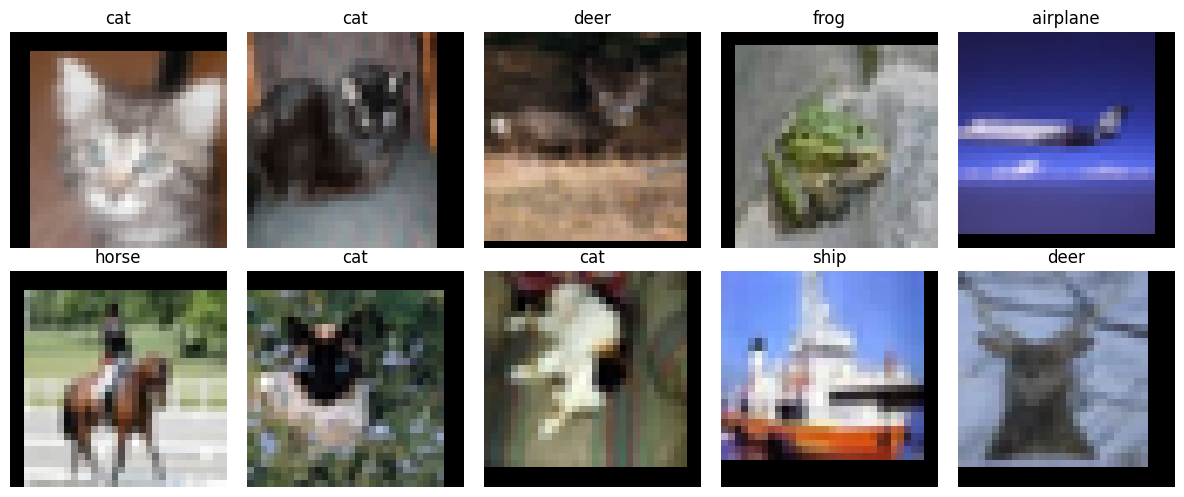

In [3]:
def imshow(img):
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

images, labels = next(iter(trainloader))
print('Batch image shape:', images.shape)
print('Batch label shape:', labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(images[i]))
    ax.set_title(classes[labels[i].item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
from torchvision import transforms

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform_train_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_eval_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [5]:
# Tạo transform riêng cho ViT
# Normalize theo ImageNet vì sử dụng mô hình pretrained
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Train có augmentation
transform_train_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Test không dùng augmentation ngẫu nhiên
transform_test_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
# Tạo dataset và DataLoader dành cho ViT
full_train_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train_vit
)

# Dataset validation: không dùng augmentation ngẫu nhiên
full_val_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_test_vit
)

# Dataset test: không dùng augmentation ngẫu nhiên
test_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test_vit
)

# ==========================================
# CHIA 80% TRAIN - 20% VALIDATION
# ==========================================

dataset_size = len(full_train_dataset_vit)
train_size = int(0.8 * dataset_size)

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    dataset_size,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# ==========================================
# TẠO SUBSET
# ==========================================

train_dataset_vit = Subset(
    full_train_dataset_vit,
    train_indices
)

val_dataset_vit = Subset(
    full_val_dataset_vit,
    val_indices
)

# ==========================================
# TẠO DATALOADER
# ==========================================

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader_vit = DataLoader(
    val_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print('Train samples:', len(train_dataset_vit))
print('Validation samples:', len(val_dataset_vit))
print('Test samples:', len(test_dataset_vit))

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train samples: 40000
Validation samples: 10000
Test samples: 10000


In [6]:
# Tạo transform riêng cho ViT
# Normalize theo ImageNet vì sử dụng mô hình pretrained
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Train có augmentation
transform_train_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Test không dùng augmentation ngẫu nhiên
transform_test_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
# Tạo dataset và DataLoader dành cho ViT
full_train_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train_vit
)

# Dataset validation: không dùng augmentation ngẫu nhiên
full_val_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_test_vit
)

# Dataset test: không dùng augmentation ngẫu nhiên
test_dataset_vit = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test_vit
)

# ==========================================
# CHIA 80% TRAIN - 20% VALIDATION
# ==========================================

dataset_size = len(full_train_dataset_vit)
train_size = int(0.8 * dataset_size)

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    dataset_size,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# ==========================================
# TẠO SUBSET
# ==========================================

train_dataset_vit = Subset(
    full_train_dataset_vit,
    train_indices
)

val_dataset_vit = Subset(
    full_val_dataset_vit,
    val_indices
)

# ==========================================
# TẠO DATALOADER
# ==========================================

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader_vit = DataLoader(
    val_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print('Train samples:', len(train_dataset_vit))
print('Validation samples:', len(val_dataset_vit))
print('Test samples:', len(test_dataset_vit))

model_vit = models.vit_b_16(pretrained=True)

model_vit.heads.head = nn.Linear(
    model_vit.heads.head.in_features,
    10
)

model_vit = model_vit.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_vit.parameters(),
    lr=1e-5
)

NUM_EPOCHS = 5
train_losses_bt3 = []
train_accuracies_bt3 = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    model_vit.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_vit:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_vit(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader_vit.dataset)
    train_accuracy = 100.0 * correct / total
    elapsed_time = time.time() - start_time

    train_losses_bt3.append(train_loss)
    train_accuracies_bt3.append(train_accuracy)

    print(
        f'Epoch [{epoch + 1}/{NUM_EPOCHS}] - '
        f'Train Loss: {train_loss:.4f} - '
        f'Train Accuracy: {train_accuracy:.2f}% - '
        f'Time: {elapsed_time:.2f}s'
    )

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train samples: 40000
Validation samples: 10000
Test samples: 10000


/home/c405/.conda/envs/jupyter_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/c405/.conda/envs/jupyter_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5] - Train Loss: 0.2160 - Train Accuracy: 94.25% - Time: 466.91s
Epoch [2/5] - Train Loss: 0.0468 - Train Accuracy: 98.65% - Time: 493.87s
Epoch [3/5] - Train Loss: 0.0253 - Train Accuracy: 99.29% - Time: 500.24s
Epoch [4/5] - Train Loss: 0.0159 - Train Accuracy: 99.52% - Time: 503.77s
Epoch [5/5] - Train Loss: 0.0132 - Train Accuracy: 99.59% - Time: 504.97s


## Bài tập 4: Xây dựng mô hình Vision Transformer

- Tạo lớp `PatchEmbedding`
- Tạo lớp `VisionTransformer` cho bài toán phân loại 10 lớp

In [1]:
model_vit.eval()

correct = 0
total = 0
LOG_EVERY = 100

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader_vit):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_vit(images)

        # Lấy lớp có logits lớn nhất
        predicted = outputs.argmax(dim=1)

        # Cập nhật số lượng ảnh và số dự đoán đúng
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # In accuracy tạm thời sau mỗi 100 batch
        if (batch_idx + 1) % LOG_EVERY == 0:
            current_accuracy = 100.0 * correct / total

            print(
                f'Batch [{batch_idx + 1:4d}/{len(test_loader_vit)}] - '
                f'Acc so far: {current_accuracy:.2f}%'
            )

test_accuracy = 100.0 * correct / total

print(f'\nTest Accuracy (sau 5 epoch): {test_accuracy:.2f}%')
print(f'Correct / Total: {correct} / {total}')

NameError: name 'model_vit' is not defined

## Bài tập 5: Khởi tạo mô hình và cấu hình huấn luyện

- Khởi tạo model
- Khai báo loss function, optimizer và scheduler

In [2]:
def create_vit_model():
    model = models.vit_b_16(pretrained=True)

    model.heads.head = nn.Linear(
        model.heads.head.in_features,
        10
    )

    return model.to(device)
def train_with_lr(learning_rate, num_epochs=5):
    # Mỗi learning rate phải dùng model mới
    model = create_vit_model()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()

        train_loss_sum = 0.0
        train_total = 0

        for images, labels in train_loader_vit:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader_vit:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)

                predicted = outputs.argmax(dim=1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_accuracy = 100.0 * val_correct / val_total

        val_accuracies.append(val_accuracy)

        print(
            f'LR={learning_rate} - '
            f'Epoch [{epoch + 1}/{num_epochs}] - '
            f'Train Loss: {train_loss:.4f} - '
            f'Val Loss: {val_loss:.4f} - '
            f'Val Accuracy: {val_accuracy:.2f}%'
        )

    return {
        'learning_rate': learning_rate,
        'final_val_accuracy': val_accuracies[-1],
        'best_val_accuracy': max(val_accuracies)
    }

In [ ]:
learning_rates = [
    0.0001,
    0.0003,
    0.001
]

lr_results = []

for lr in learning_rates:
    print('\n' + '=' * 60)
    print(f'TRAINING WITH LEARNING RATE = {lr}')
    print('=' * 60)

    result = train_with_lr(
        learning_rate=lr,
        num_epochs=5
    )

    lr_results.append(result)
    
df_lr_results = pd.DataFrame(lr_results)

print(df_lr_results)

df_lr_results = pd.DataFrame([
    {
        'Learning Rate': result['learning_rate'],
        'Final Val Accuracy (%)': result['final_val_accuracy'],
        'Best Val Accuracy (%)': result['best_val_accuracy']
    }
    for result in lr_results
])

print(df_lr_results)

## Bài tập 6: Huấn luyện và đánh giá validation

- Viết hàm train cho một epoch
- Viết hàm evaluate trên validation set
- Huấn luyện mô hình theo nhiều epoch

In [ ]:
def train_with_batch_size(batch_size, learning_rate=0.00001, num_epochs=5):
    # Chỉ tạo lại train DataLoader vì batch size thay đổi
    train_loader_bs = DataLoader(
        train_dataset_vit,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    # Mỗi thí nghiệm dùng model mới để so sánh công bằng
    model = create_vit_model()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    val_accuracies = []

    start_total = time.time()

    for epoch in range(num_epochs):
        # =========================
        # TRAIN
        # =========================
        model.train()

        train_loss_sum = 0.0
        train_total = 0

        for images, labels in train_loader_bs:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader_vit:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)

                predicted = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_accuracy = 100.0 * val_correct / val_total

        val_accuracies.append(val_accuracy)

        print(
            f'Batch Size={batch_size} - '
            f'Epoch [{epoch + 1}/{num_epochs}] - '
            f'Train Loss: {train_loss:.4f} - '
            f'Val Loss: {val_loss:.4f} - '
            f'Val Accuracy: {val_accuracy:.2f}%'
        )

    total_time = time.time() - start_total

    return {
        'Batch Size': batch_size,
        'Final Val Accuracy (%)': val_accuracies[-1],
        'Best Val Accuracy (%)': max(val_accuracies),
        'Total Time (s)': total_time
    }

batch_sizes = [16, 32, 64]

batch_results = []

for batch_size in batch_sizes:
    print('\n' + '=' * 60)
    print(f'TRAINING WITH BATCH SIZE = {batch_size}')
    print('=' * 60)

    result = train_with_batch_size(
        batch_size=batch_size,
        learning_rate=0.0001,
        num_epochs=5
    )

    batch_results.append(result)

df_batch_results = pd.DataFrame(batch_results)

print(df_batch_results)

## Bài tập 7: Vẽ biểu đồ loss và accuracy

- Vẽ train loss và validation loss
- Vẽ train accuracy và validation accuracy

Epoch [1/5] - Train Loss: 1.6914 - Val Loss: 1.4951 - Val Accuracy: 46.11%
Epoch [2/5] - Train Loss: 1.4333 - Val Loss: 1.4149 - Val Accuracy: 50.40%
Epoch [3/5] - Train Loss: 1.2768 - Val Loss: 1.2767 - Val Accuracy: 54.85%
Epoch [4/5] - Train Loss: 1.1576 - Val Loss: 1.1970 - Val Accuracy: 58.49%
Epoch [5/5] - Train Loss: 1.0647 - Val Loss: 1.1911 - Val Accuracy: 58.10%

CNN Test Accuracy: 58.52 %
CNN Correct / Total: 5852 / 10000
CNN Training Time: 177.92 s

Comparison between ViT and CNN:
                           Model  Test Accuracy (%)
0  Vision Transformer (ViT-B/16)              97.52
1                     Simple CNN              58.52


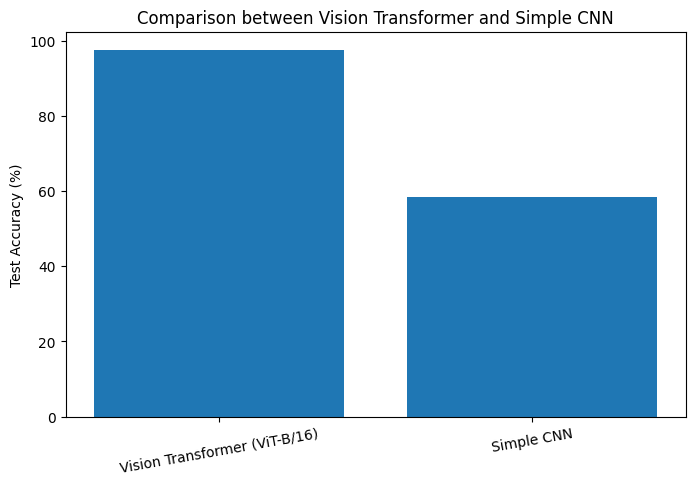

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224x224 -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 112x112 -> 56x56
        )

        self.fc = nn.Linear(64 * 56 * 56, 10)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x


model_cnn = SimpleCNN().to(device)

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

NUM_EPOCHS_CNN = 5

cnn_train_losses = []
cnn_val_losses = []
cnn_val_accuracies = []

start_time = time.time()

for epoch in range(NUM_EPOCHS_CNN):
    model_cnn.train()

    train_loss_sum = 0.0
    train_total = 0

    for images, labels in train_loader_vit:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_cnn.zero_grad()

        outputs = model_cnn(images)
        loss = criterion_cnn(outputs, labels)

        loss.backward()
        optimizer_cnn.step()

        train_loss_sum += loss.item() * images.size(0)
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    cnn_train_losses.append(train_loss)

    model_cnn.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    validation_loader = val_loader_vit if 'val_loader_vit' in globals() else test_loader_vit

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_cnn(images)
            loss = criterion_cnn(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)

            predicted = outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_accuracy = 100.0 * val_correct / val_total

    cnn_val_losses.append(val_loss)
    cnn_val_accuracies.append(val_accuracy)

    print(
        f'Epoch [{epoch + 1}/{NUM_EPOCHS_CNN}] - '
        f'Train Loss: {train_loss:.4f} - '
        f'Val Loss: {val_loss:.4f} - '
        f'Val Accuracy: {val_accuracy:.2f}%'
    )

cnn_training_time = time.time() - start_time


model_cnn.eval()

cnn_correct = 0
cnn_total = 0

with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)
        predicted = outputs.argmax(dim=1)

        cnn_total += labels.size(0)
        cnn_correct += (predicted == labels).sum().item()

cnn_test_accuracy = 100.0 * cnn_correct / cnn_total

print('\nCNN Test Accuracy:', round(cnn_test_accuracy, 2), '%')
print('CNN Correct / Total:', cnn_correct, '/', cnn_total)
print('CNN Training Time:', round(cnn_training_time, 2), 's')

if 'vit_test_accuracy' not in globals():
    vit_test_accuracy = test_accuracy

comparison_df = pd.DataFrame([
    {
        'Model': 'Vision Transformer (ViT-B/16)',
        'Test Accuracy (%)': vit_test_accuracy
    },
    {
        'Model': 'Simple CNN',
        'Test Accuracy (%)': cnn_test_accuracy
    }
])

print('\nComparison between ViT and CNN:')
print(comparison_df)


plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df['Model'],
    comparison_df['Test Accuracy (%)']
)

plt.ylabel('Test Accuracy (%)')
plt.title('Comparison between Vision Transformer and Simple CNN')
plt.xticks(rotation=10)
plt.show()

## Bài tập 8: Đánh giá test, confusion matrix và lưu model

- Đánh giá trên test set
- Tính confusion matrix
- In classification report
- Lưu trọng số mô hình

In [7]:
# ==========================================
# HÀM DÙNG CHUNG CHO BÀI 8 VÀ BÀI 9
# ==========================================

import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

def train_vit_model(
    model,
    train_loader,
    val_loader,
    learning_rate=0.0001,
    num_epochs=5
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(num_epochs):
        # =========================
        # TRAINING
        # =========================
        model.train()

        train_loss_sum = 0.0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_losses.append(train_loss)

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)

                predicted = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_accuracy = 100.0 * val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f'Epoch [{epoch + 1}/{num_epochs}] - '
            f'Train Loss: {train_loss:.4f} - '
            f'Val Loss: {val_loss:.4f} - '
            f'Val Accuracy: {val_accuracy:.2f}%'
        )

    training_time = time.time() - start_time

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'training_time': training_time
    }


def evaluate_accuracy(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total

    return accuracy, correct, total

bài 8

In [8]:
# ==========================================
# BÀI 8: THỬ DATASET CIFAR-100
# ==========================================

# =========================
# 1. Tạo dataset CIFAR-100
# =========================

# Train có augmentation
full_trainset_cifar100 = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train_vit
)

# Validation không dùng augmentation ngẫu nhiên
full_valset_cifar100 = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_eval_vit
)

# Test không dùng augmentation ngẫu nhiên
testset_cifar100 = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_eval_vit
)

# =========================
# 2. Chia 80% train - 20% validation
# =========================

dataset_size_cifar100 = len(full_trainset_cifar100)
train_size_cifar100 = int(0.8 * dataset_size_cifar100)

generator = torch.Generator().manual_seed(42)

indices_cifar100 = torch.randperm(
    dataset_size_cifar100,
    generator=generator
).tolist()

train_indices_cifar100 = indices_cifar100[:train_size_cifar100]
val_indices_cifar100 = indices_cifar100[train_size_cifar100:]

trainset_cifar100 = Subset(
    full_trainset_cifar100,
    train_indices_cifar100
)

valset_cifar100 = Subset(
    full_valset_cifar100,
    val_indices_cifar100
)

# =========================
# 3. Tạo DataLoader
# =========================

train_loader_cifar100 = DataLoader(
    trainset_cifar100,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader_cifar100 = DataLoader(
    valset_cifar100,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader_cifar100 = DataLoader(
    testset_cifar100,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print('Train samples:', len(trainset_cifar100))
print('Validation samples:', len(valset_cifar100))
print('Test samples:', len(testset_cifar100))

# =========================
# 4. Khởi tạo ViT-B/16
# =========================

model_vit_cifar100 = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

# CIFAR-100 có 100 lớp
model_vit_cifar100.heads.head = nn.Linear(
    model_vit_cifar100.heads.head.in_features,
    100
)

model_vit_cifar100 = model_vit_cifar100.to(device)

# =========================
# 5. Train 5 epoch
# =========================

history_cifar100 = train_vit_model(
    model=model_vit_cifar100,
    train_loader=train_loader_cifar100,
    val_loader=val_loader_cifar100,
    learning_rate=0.0001,
    num_epochs=5
)

# =========================
# 6. Test accuracy
# =========================

cifar100_test_accuracy, cifar100_correct, cifar100_total = evaluate_accuracy(
    model_vit_cifar100,
    test_loader_cifar100
)

print('\nCIFAR-100 Test Accuracy:', round(cifar100_test_accuracy, 2), '%')
print('Correct / Total:', cifar100_correct, '/', cifar100_total)
print('Training Time:', round(history_cifar100['training_time'], 2), 's')

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train samples: 40000
Validation samples: 10000
Test samples: 10000


Epoch [1/5] - Train Loss: 1.1289 - Val Loss: 0.7600 - Val Accuracy: 77.57%
Epoch [2/5] - Train Loss: 0.4924 - Val Loss: 0.8094 - Val Accuracy: 76.98%
Epoch [3/5] - Train Loss: 0.3383 - Val Loss: 0.6963 - Val Accuracy: 79.56%
Epoch [4/5] - Train Loss: 0.2616 - Val Loss: 0.7516 - Val Accuracy: 79.36%
Epoch [5/5] - Train Loss: 0.2012 - Val Loss: 0.7760 - Val Accuracy: 79.14%

CIFAR-100 Test Accuracy: 79.97 %
Correct / Total: 7997 / 10000
Training Time: 2724.58 s


bai 9

In [ ]:
model_vit_b32 = models.vit_b_32(
    weights=models.ViT_B_32_Weights.DEFAULT
)

# CIFAR-10 có 10 lớp
model_vit_b32.heads.head = nn.Linear(
    model_vit_b32.heads.head.in_features,
    10
)

model_vit_b32 = model_vit_b32.to(device)

# 2. Train 5 epoch

history_vit_b32 = train_vit_model(
    model=model_vit_b32,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    learning_rate=0.0001,
    num_epochs=5
)

# 3. Test accuracy

vit_b32_test_accuracy, vit_b32_correct, vit_b32_total = evaluate_accuracy(
    model_vit_b32,
    test_loader_vit
)

print('\nViT-B/32 Test Accuracy:', round(vit_b32_test_accuracy, 2), '%')
print('Correct / Total:', vit_b32_correct, '/', vit_b32_total)
print('Training Time:', round(history_vit_b32['training_time'], 2), 's')


Epoch [1/5] - Train Loss: 0.4800 - Val Loss: 0.3071 - Val Accuracy: 89.57%
Epoch [2/5] - Train Loss: 0.2458 - Val Loss: 0.3475 - Val Accuracy: 88.37%
Epoch [3/5] - Train Loss: 0.1900 - Val Loss: 0.2816 - Val Accuracy: 90.69%
Epoch [4/5] - Train Loss: 0.1557 - Val Loss: 0.2912 - Val Accuracy: 90.60%
Epoch [5/5] - Train Loss: 0.1330 - Val Loss: 0.3298 - Val Accuracy: 89.11%

ViT-B/32 Test Accuracy: 88.87 %
Correct / Total: 8887 / 10000
Training Time: 777.79 s


NameError: name 'vit_test_accuracy' is not defined

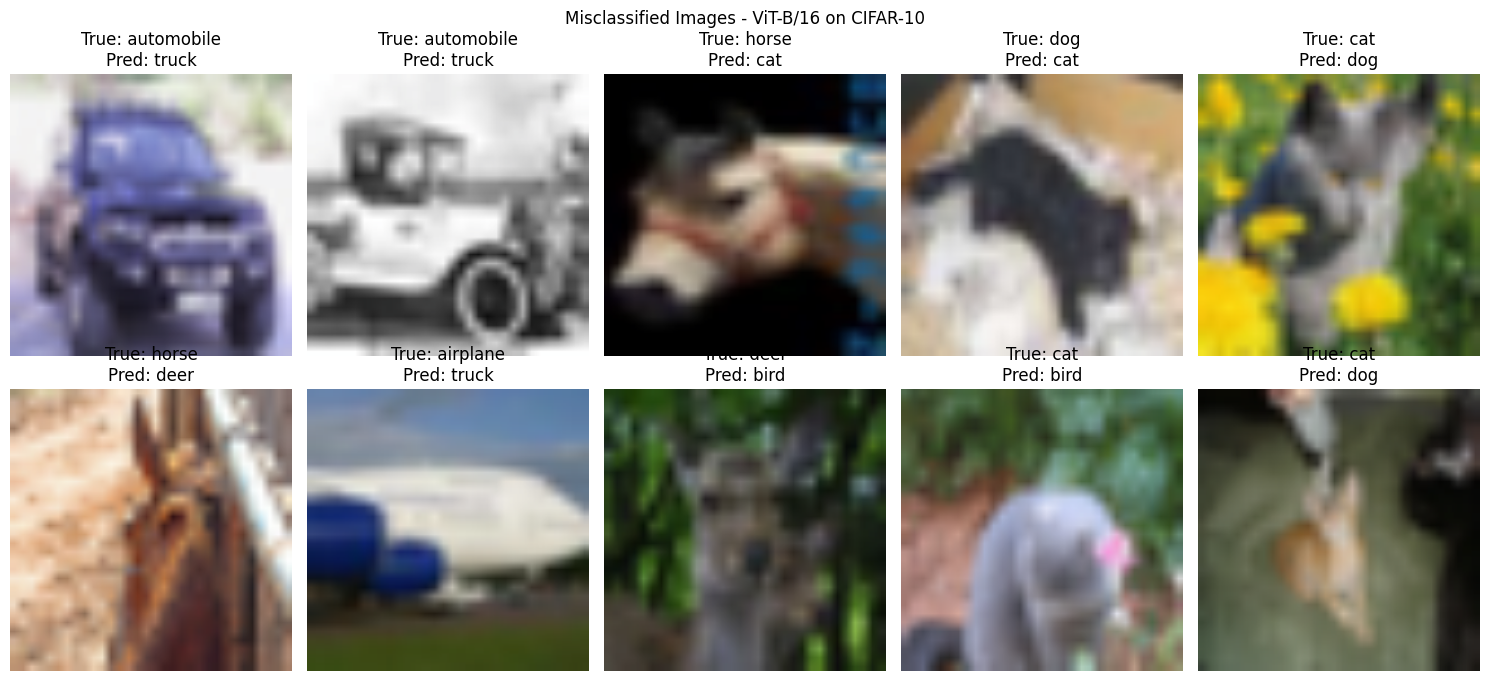

In [10]:
# ==========================================
# BÀI 10: PHÂN TÍCH CÁC DỰ ĐOÁN SAI
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# Normalize đã dùng cho pretrained ViT
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def denormalize_image(image_tensor):
    """
    Chuyển tensor từ dạng Normalize về ảnh có thể hiển thị.
    """
    image = image_tensor.cpu().permute(1, 2, 0).numpy()

    image = image * IMAGENET_STD + IMAGENET_MEAN

    image = np.clip(image, 0, 1)

    return image


model_vit.eval()

misclassified_images = []
true_labels = []
predicted_labels = []

MAX_WRONG_IMAGES = 10

with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_vit(images)
        predictions = outputs.argmax(dim=1)

        wrong_mask = predictions != labels

        wrong_images = images[wrong_mask]
        wrong_true_labels = labels[wrong_mask]
        wrong_predictions = predictions[wrong_mask]

        for image, true_label, predicted_label in zip(
            wrong_images,
            wrong_true_labels,
            wrong_predictions
        ):
            misclassified_images.append(image.cpu())
            true_labels.append(true_label.item())
            predicted_labels.append(predicted_label.item())

            if len(misclassified_images) >= MAX_WRONG_IMAGES:
                break

        if len(misclassified_images) >= MAX_WRONG_IMAGES:
            break

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for index, ax in enumerate(axes.flat):
    image = denormalize_image(
        misclassified_images[index]
    )

    ax.imshow(image)

    ax.set_title(
        f'True: {classes[true_labels[index]]}\n'
        f'Pred: {classes[predicted_labels[index]]}'
    )

    ax.axis('off')

plt.suptitle('Misclassified Images - ViT-B/16 on CIFAR-10')
plt.tight_layout()
plt.show()